# Line Tracing

Follow the yellow track line with three ideas: an **HSV color filter** isolates the line's pixels, their center gives the line's **offset** from image center, and **proportional steering** turns toward it. No learning, no model — classic robotics.

## [1] Setup

### 1.1. Talking to the car

The API takes radians; we work in degrees (+ = left). A speed command without `duration` expires after ~1 s (safety watchdog: a crashed program must not leave the car driving) — the drive loop re-sends it every frame, renewing the watchdog.

In [1]:
import os

DIR = "assets/line-tracing"
if not os.path.isdir(DIR):               # kernel cwd is the workspace root
    DIR = "examples/" + DIR

import math

import cv2
import numpy as np
import requests

BASE_URL = "http://localhost"


def camera():
    """Latest camera frame as a BGR image (ndarray)."""
    jpg = requests.get(f"{BASE_URL}/camera", timeout=2).content
    return cv2.imdecode(np.frombuffer(jpg, np.uint8), cv2.IMREAD_COLOR)


def drive(speed, steering):
    """speed in m/s, steering in degrees (+ = left). The API wants radians."""
    requests.post(f"{BASE_URL}/speed", json={"value": float(speed)}, timeout=2)
    requests.post(f"{BASE_URL}/steering",
                  json={"value": math.radians(steering)}, timeout=2)

/home/physicar/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


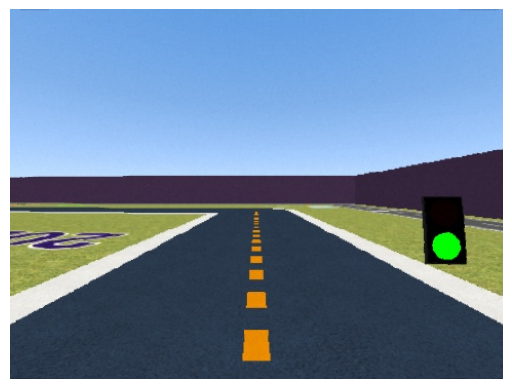

In [2]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(camera(), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## [2] Finding the line

### 2.1. The color filter

Convert to HSV (hue survives lighting changes far better than RGB), keep only pixels in the yellow range, and blank the top half (the line that matters is the road right in front). The mask's center of mass, normalized to −1..1, is the line offset. Fewer than 1000 yellow pixels = no line.

In [3]:
YELLOW_LO = (20, 80, 80)     # HSV range of the yellow line
YELLOW_HI = (35, 255, 255)


def find_line_offset(img):
    """Return the yellow line's horizontal offset from image center,
    normalized to [-1, 1] (None if no line is visible), plus the mask."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, YELLOW_LO, YELLOW_HI)
    mask[:img.shape[0] // 2] = 0             # look at the lower half (near road)
    m = cv2.moments(mask)
    if m["m00"] < 1000:                       # too few yellow pixels
        return None, mask
    cx = m["m10"] / m["m00"]
    return (cx - img.shape[1] / 2) / (img.shape[1] / 2), mask

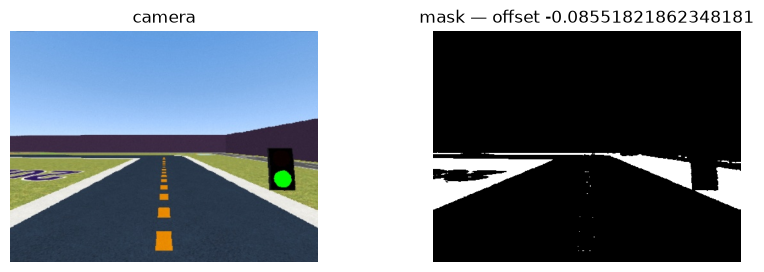

In [4]:
img = camera()
offset, mask = find_line_offset(img)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax[0].set_title("camera")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title(f"mask — offset {offset}")
for a in ax: a.axis("off")
plt.show()

### 2.2. Offset → steering

Proportional control: steer against the offset, harder the further the line drifts, clamped to the ±20° hardware limit. The minus sign: line to the right (positive offset) → steer right (negative). When the line is lost, creep forward at 0.3 m/s turning +15° until it reappears.

In [5]:
SPEED = 0.5            # m/s while the line is visible
STEER_GAIN = 20.0      # how hard to steer per unit of line offset

for offset in (-1.0, -0.5, 0.0, 0.5, 1.0):
    print(f"offset {offset:+.1f}  ->  steering {max(-20, min(20, -offset * STEER_GAIN)):+.1f} deg")

offset -1.0  ->  steering +20.0 deg
offset -0.5  ->  steering +10.0 deg
offset +0.0  ->  steering -0.0 deg
offset +0.5  ->  steering -10.0 deg
offset +1.0  ->  steering -20.0 deg


## [3] Drive

### 3.1. The live view

The web view is plumbing, not the logic — run the cell and forget it (the pages themselves live in the example's folder). It skips itself with a notice when port 5000 is already taken by another app.

In [7]:
"""Live web view (MYAPP tab, port 5000): the camera with every pixel that
passed the yellow filter repainted magenta -- exactly what the code steers
by -- plus the image center (white) and the detected line position (magenta)."""
import socket
import threading

_server = [None]     # the one live web view — a new serve() replaces it


def stop_view():
    if _server[0]:
        _server[0].shutdown()
        _server[0] = None


def _start(app):
    import logging
    logging.getLogger("werkzeug").setLevel(logging.ERROR)
    from werkzeug.serving import make_server
    stop_view()                      # one view at a time — replace the old one
    try:
        probe = socket.socket()                       # quiet pre-check: werkzeug
        probe.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)   # prints and
        probe.bind(("", 5000))                        # exits on a busy port
        probe.close()
        server = make_server("0.0.0.0", 5000, app, threaded=True)
    except (OSError, SystemExit):
        print("web view: port 5000 is in use by another example — "
              "interrupt (⏹) that cell or restart its kernel; "
              "continuing without the live view")
        return None
    _server[0] = server
    threading.Thread(target=server.serve_forever, daemon=True).start()
    print("web view: open the MYAPP tab to watch")
    return server

_frame = [b""]          # latest composited camera frame as JPEG
_status = [""]

_MAGENTA = (255, 0, 255)    # BGR -- a color that never occurs on the track


def update(img_bgr, mask, offset, steering, status):
    img = img_bgr.copy()
    img[mask > 0] = _MAGENTA    # the pixels the code actually steers by
    h, w = img.shape[:2]
    cv2.line(img, (w // 2, 0), (w // 2, h), (255, 255, 255), 1)
    if offset is not None:
        cx = int(w / 2 + offset * w / 2)
        cv2.line(img, (cx, 0), (cx, h), _MAGENTA, 2)
    _frame[0] = cv2.imencode(".jpg", img)[1].tobytes()
    _status[0] = status


def serve():
    from flask import Flask, Response, jsonify
    app = Flask(__name__)
    page = open(f"{DIR}/webui.html").read()   # presentation lives in the folder

    @app.get("/")
    def index():
        return page

    @app.get("/frame")
    def frame():
        return Response(_frame[0], mimetype="image/jpeg",
                        headers={"Cache-Control": "no-store"})

    @app.get("/data")
    def data():
        return jsonify({"status": _status[0]})

    return _start(app)

### 3.2. Follow the line

Runs until you interrupt the cell (⏹) — the `finally` block stops the car. Watch the **MYAPP tab** while it drives.

In [8]:
import time

serve()   # MYAPP tab: camera + mask + line offset, live
try:
    while True:
        t0 = time.time()
        img = camera()
        offset, mask = find_line_offset(img)

        if offset is None:
            steering = 15
            drive(0.3, steering)          # search: creep and turn
            status = "line lost — searching"
        else:
            steering = max(-20, min(20, -offset * STEER_GAIN))
            drive(SPEED, steering)
            status = f"offset {offset:+.2f}  steering {steering:+.1f}"
        update(img, mask, offset, steering, status)
        time.sleep(max(0.0, 1 / 15 - (time.time() - t0)))
except KeyboardInterrupt:
    pass
finally:
    drive(0, 0)
    stop_view()   # the live view lives and dies with this cell
    print("stopped")

web view: open the MYAPP tab to watch
stopped
